# Impact of Missing Data Imputation Methods on Diabetes Prediction

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from upsetplot import UpSet, from_indicators

import statsmodels.api as sm

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
raw_data = pd.read_csv("Diabetes.csv")
data = raw_data.copy()
data['Pregnancies'] = data['Pregnancies'].fillna(0)

## 1. Missing Data Exploration

### 1.1 Missing Value Summary

We begin by summarizing the amount of missing data in each variable.

This step is important because variables with high missingness require special attention before any anomaly detection model is applied. In particular, if a variable contains a large proportion of missing values, simple deletion may cause substantial information loss.

In [8]:
miss_summary = pd.DataFrame({
    'variable': data.columns,
    'n_miss': data.isna().sum().values,
    'pct_miss': (data.isna().mean().values * 100).round(3)
}).sort_values(by='n_miss', ascending=False)

print(miss_summary)

                   variable  n_miss  pct_miss
4                   Insulin     374    48.698
3             SkinThickness     227    29.557
2             BloodPressure      35     4.557
5                       BMI      11     1.432
1                   Glucose       5     0.651
0               Pregnancies       0     0.000
6  DiabetesPedigreeFunction       0     0.000
7                       Age       0     0.000
8                  Diabetes       0     0.000


### 1.2 Missing Value Visualization

To complement the summary table, we visualize the number of missing values for each variable.

This makes it easier to compare variables directly and identify which features are most heavily affected by missingness.

/opt/anaconda3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/opt/anaconda3/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

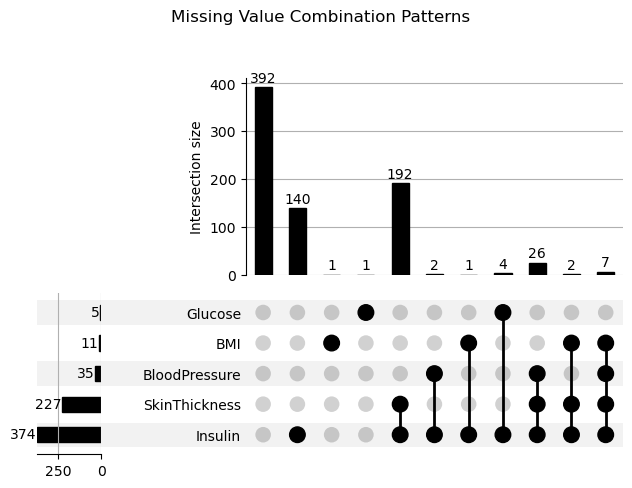

In [9]:
from upsetplot import UpSet, from_indicators
import matplotlib.pyplot as plt

missing_matrix = data[['Glucose', 'BMI', 'BloodPressure', 'SkinThickness', 'Insulin']].isna()

upset_data = from_indicators(missing_matrix.columns, missing_matrix)

up = UpSet(upset_data, subset_size='count', show_counts=True)
up.plot()

plt.suptitle("Missing Value Combination Patterns", y=1.02)
plt.show()

### 1.3 Missingness Pattern Analysis

After quantifying the amount of missing data, we next examine the overall missingness pattern across observations.

The purpose of this step is to see whether missing values occur independently or whether some observations tend to have several missing variables at the same time.

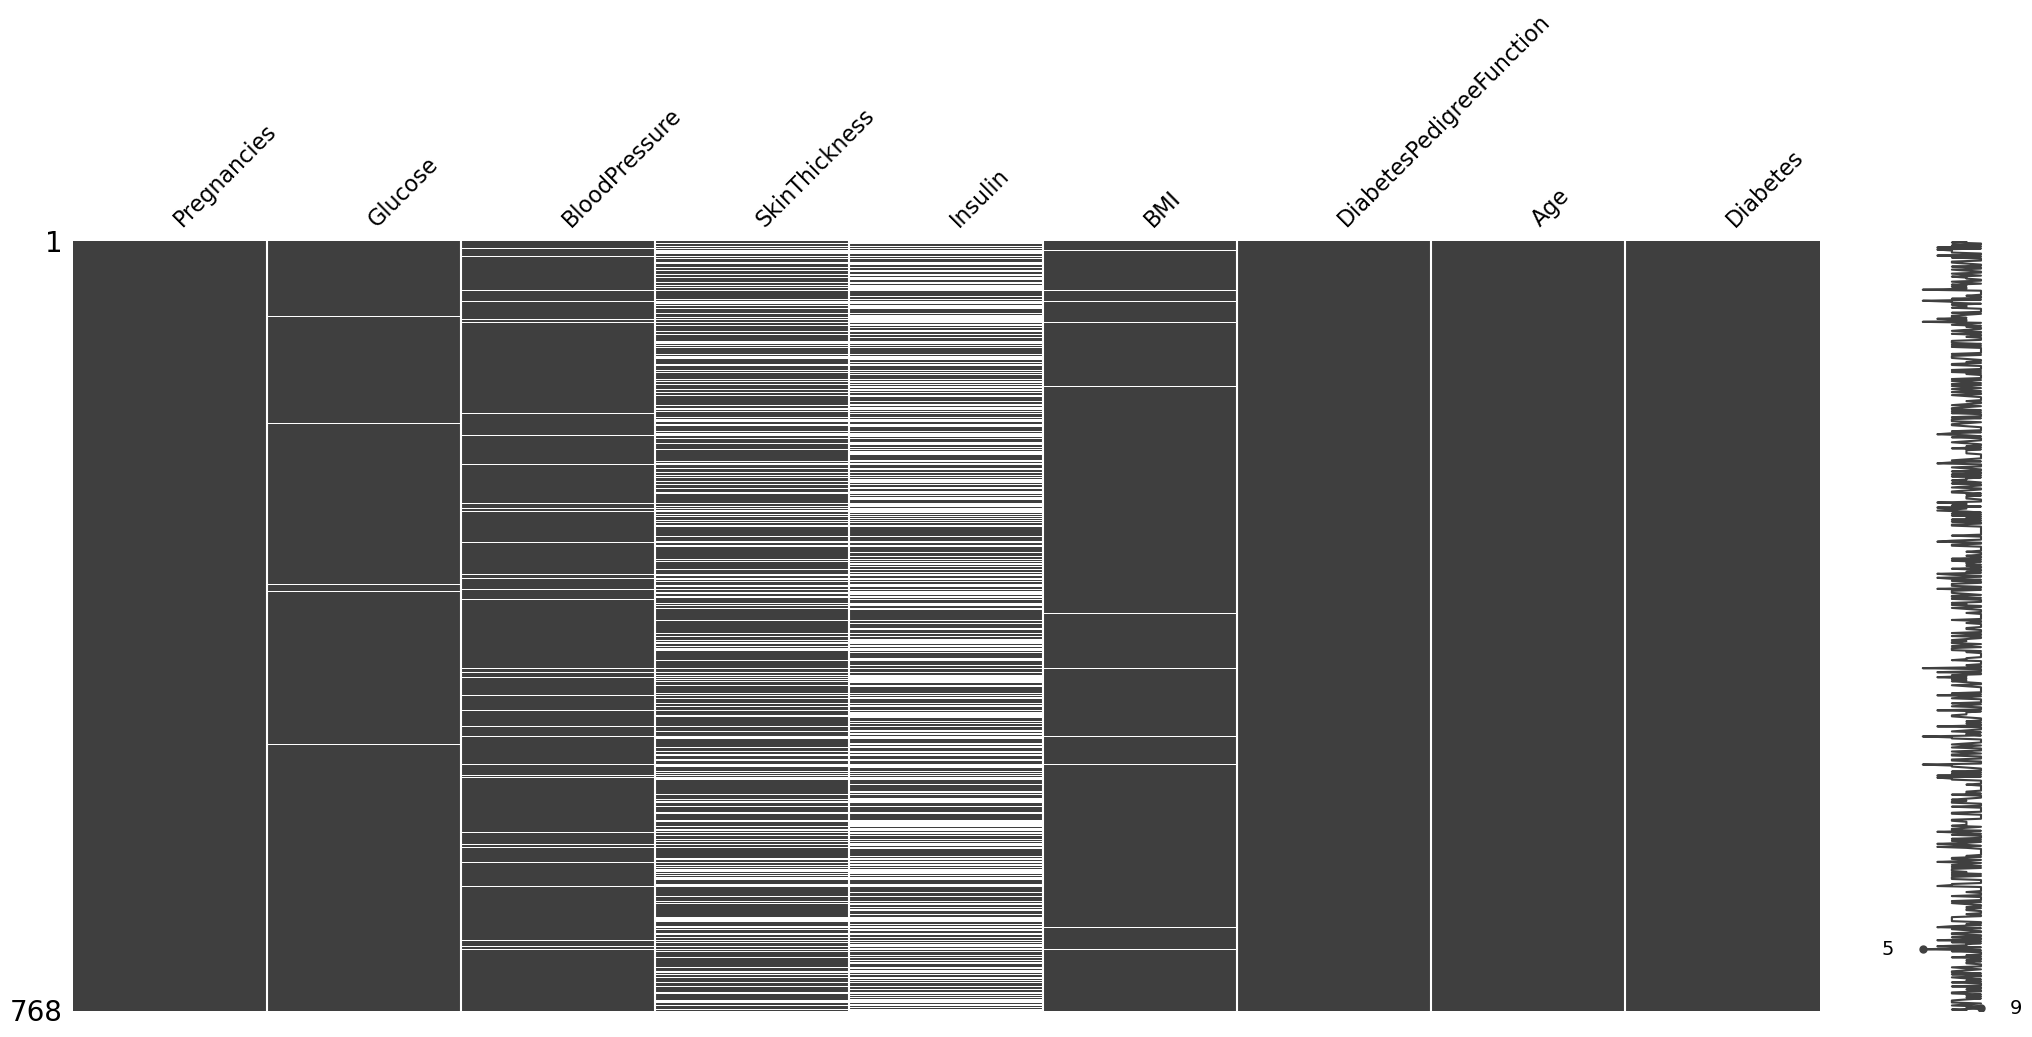

In [10]:
msno.matrix(data)
plt.show()

### 1.4 Missingness Co-occurrence Structure

We further investigate whether missing values tend to occur together across variables.

If multiple variables frequently become missing at the same time, this suggests that the missingness may follow a structured mechanism rather than occurring completely at random.

The missingness heatmap shows a strong positive correlation (~0.7) between SkinThickness and Insulin, indicating that these two variables tend to be missing together. This repeated co-missing pattern suggests that the missingness is structured rather than independent.

This provides evidence against MCAR and makes a MAR mechanism more plausible.

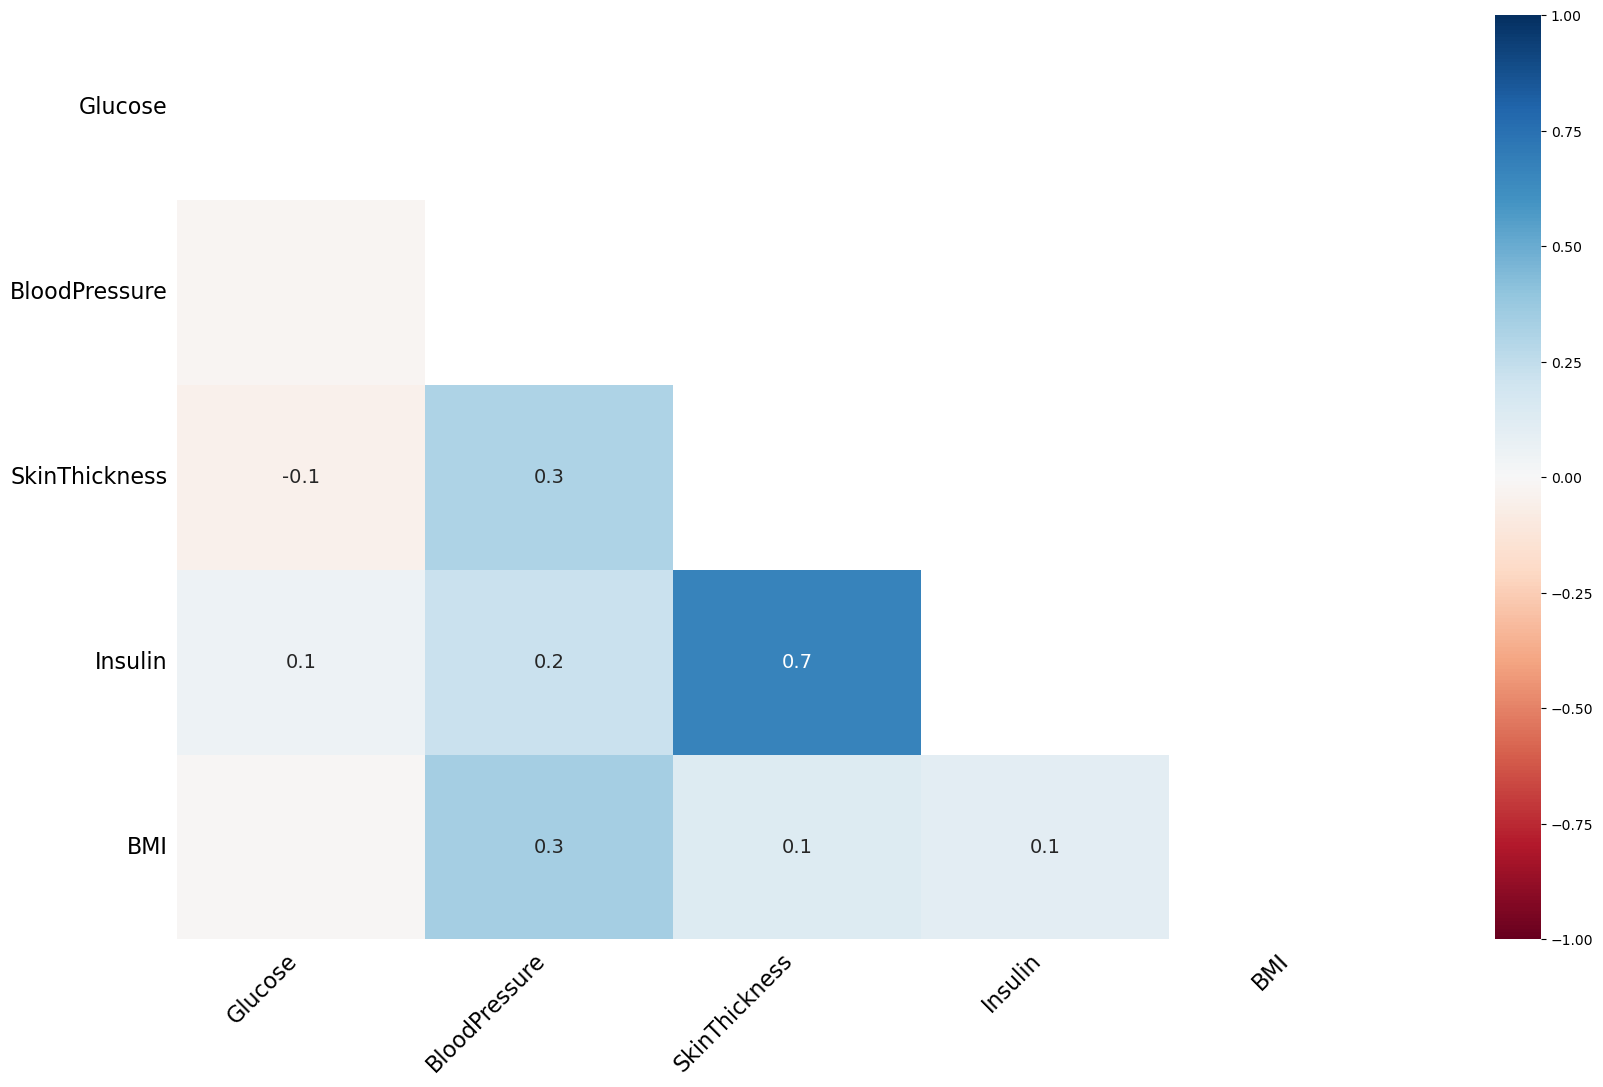

In [11]:
msno.heatmap(data)
plt.show()

### 1.5 Relationship Between Missingness and Observed Variables

To further assess whether missingness may depend on observed variables, we compared the distributions of Variables by Insulin missingness status.

Insulin was selected as the primary variable for missingness exploration because it contains one of the highest proportions of missing values in the dataset and is clinically important for diabetes-related analysis.

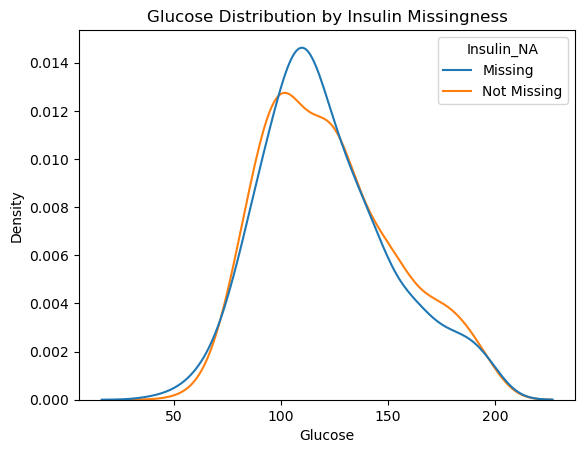

In [12]:
data_shadow = data.copy()
data_shadow['Insulin_NA'] = np.where(data_shadow['Insulin'].isna(), 'Missing', 'Not Missing')

sns.kdeplot(data=data_shadow, x='Glucose', hue='Insulin_NA', common_norm=False)
plt.title("Glucose Distribution by Insulin Missingness")
plt.show()

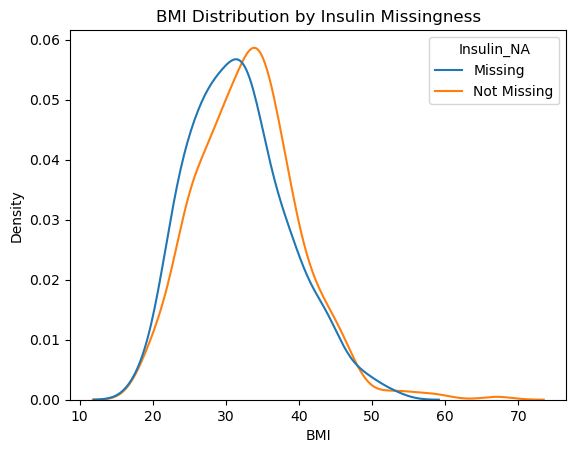

In [13]:
data_shadow['Insulin_NA'] = np.where(data_shadow['Insulin'].isna(), 'Missing', 'Not Missing')

sns.kdeplot(data=data_shadow, x='BMI', hue='Insulin_NA', common_norm=False)
plt.title("BMI Distribution by Insulin Missingness")
plt.show()

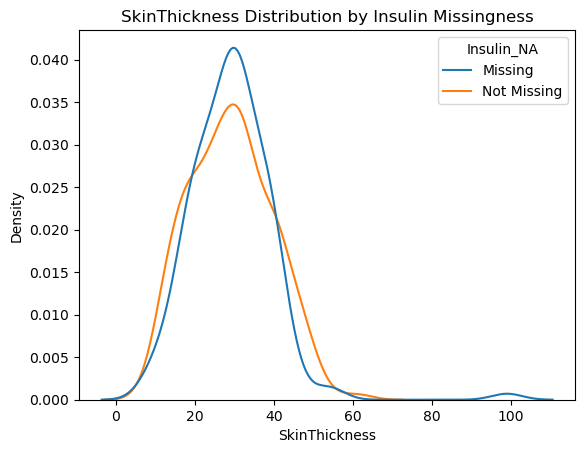

In [14]:
data_shadow['Insulin_NA'] = np.where(data_shadow['Insulin'].isna(), 'Missing', 'Not Missing')

sns.kdeplot(data=data_shadow, x='SkinThickness', hue='Insulin_NA', common_norm=False)
plt.title("SkinThickness Distribution by Insulin Missingness")
plt.show()

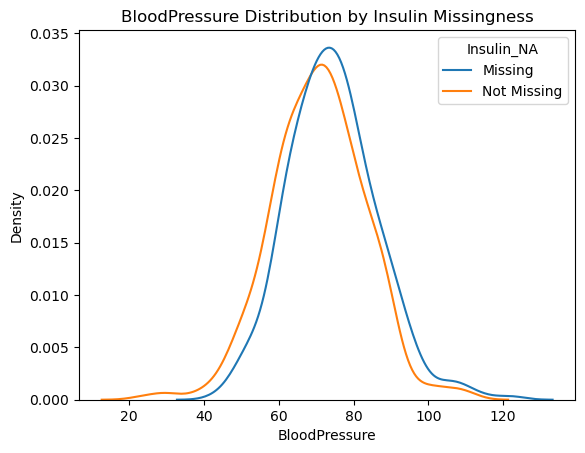

In [15]:
data_shadow['Insulin_NA'] = np.where(data_shadow['Insulin'].isna(), 'Missing', 'Not Missing')

sns.kdeplot(data=data_shadow, x='BloodPressure', hue='Insulin_NA', common_norm=False)
plt.title("BloodPressure Distribution by Insulin Missingness")
plt.show()

#### Conclusion of Missingness Exploration

Based on the KDE comparisons between rows with missing and non-missing Insulin values:

- **Glucose:** The missing group showed a higher peak, suggesting that missing Insulin values may be concentrated within a specific glucose range.
- **BMI:** The missing group was slightly shifted to the left, indicating that lower BMI values may be more associated with missing Insulin.
- **SkinThickness:** The missing group also showed a higher peak, suggesting clustering within a narrower range of skin thickness values.
- **BloodPressure:** The non-missing group was slightly shifted to the left, showing a modest distributional difference between groups.

Overall, while the differences were subtle, the repeated shifts and peak differences across multiple observed variables suggest that the missingness in **Insulin** is unlikely to be completely random. Therefore, a **MAR (Missing At Random)** mechanism appears more plausible than strict **MCAR**.

### 1.6 Scatter Plot of BMI and Insulin Missingness

We also examine the relationship between BMI and Insulin while explicitly marking observations where Insulin is missing.

This visualization helps us understand whether missing Insulin values are concentrated in a particular BMI range or spread broadly across the sample.

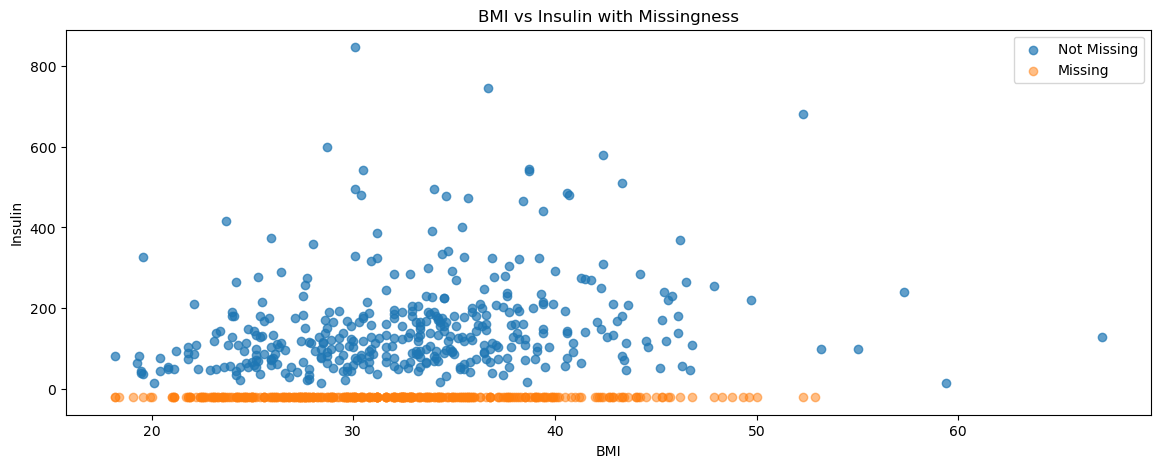

In [16]:
non_missing = data[data['Insulin'].notna()]
missing = data[data['Insulin'].isna()]

plt.figure(figsize=(14,5))
plt.scatter(non_missing['BMI'], non_missing['Insulin'], alpha=0.7, label='Not Missing')
plt.scatter(missing['BMI'], [-20]*len(missing), alpha=0.5, label='Missing')
plt.xlabel("BMI")
plt.ylabel("Insulin")
plt.title("BMI vs Insulin with Missingness")
plt.legend()
plt.show()

In the extremely high BMI range (>50), only a few observations are present, and most of them have observed Insulin values. While this may suggest that higher-BMI patients were more likely to receive Insulin measurements, the small sample size limits strong conclusions.

## 2 Missing Data Imputation

### 2.1 Mean Imputation
Replace missing values with the mean of each numeric variable.
This provides the simplest baseline imputation method.

In [17]:
numeric_cols = data.select_dtypes(include='number').columns

mean_imp = data.copy()

imputer_mean = SimpleImputer(strategy='mean')
mean_imp[numeric_cols] = imputer_mean.fit_transform(mean_imp[numeric_cols])

### 2.2 Median Imputation
- Replace missing values with the median of each numeric variable.

- This method is more robust to skewed distributions and outliers.

In [18]:
median_imp = data.copy()

imputer_median = SimpleImputer(strategy='median')
median_imp[numeric_cols] = imputer_median.fit_transform(median_imp[numeric_cols])

### 2.3 Mode and Constant Imputation
- Apply mode imputation and constant-value imputation as additional simple baselines.

- These methods help compare how different filling strategies affect the data.

In [19]:
mode_imp = data.copy()
constant_imp = data.copy()

imputer_mode = SimpleImputer(strategy='most_frequent')
imputer_constant = SimpleImputer(strategy='constant', fill_value=0)

mode_imp[numeric_cols] = imputer_mode.fit_transform(mode_imp[numeric_cols])
constant_imp[numeric_cols] = imputer_constant.fit_transform(constant_imp[numeric_cols])

### 2.4 Compare BMI Distribution
- Visualize the BMI distribution before and after imputation using KDE plots.

- This helps identify distribution distortion caused by simple imputation methods.

Although the overall BMI distribution remains visually similar after mean and median imputation, a slightly sharper peak appears around the center of the distribution. This indicates that missing values are being concentrated near the central tendency, leading to mild variance shrinkage.

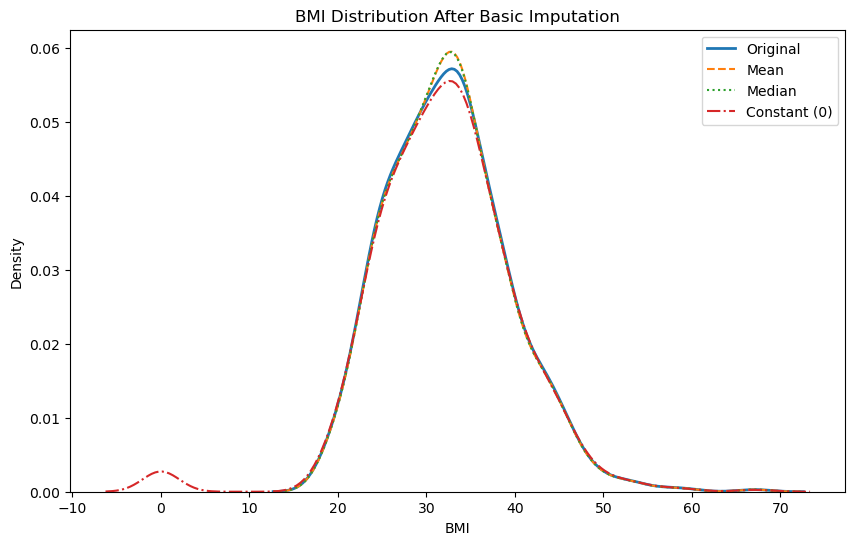

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(data['BMI'].dropna(), label='Original', linewidth=2)
sns.kdeplot(mean_imp['BMI'], label='Mean', linestyle='--')
sns.kdeplot(median_imp['BMI'], label='Median', linestyle=':')
sns.kdeplot(constant_imp['BMI'], label='Constant (0)', linestyle='-.')

plt.title("BMI Distribution After Basic Imputation")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()
plt.show()

### 2.6 Final Missing Value Verification
Verify that all missing values were successfully removed after each imputation method.
This ensures the datasets are ready for downstream analysis.

In [21]:
print("Mean:", mean_imp[numeric_cols].isna().sum().sum())
print("Median:", median_imp[numeric_cols].isna().sum().sum())
print("Mode:", mode_imp[numeric_cols].isna().sum().sum())
print("Constant:", constant_imp[numeric_cols].isna().sum().sum())

Mean: 0
Median: 0
Mode: 0
Constant: 0


## 3. Advanced Imputation
In this section, we applied more advanced imputation techniques that consider relationships between variables instead of replacing missing values with a single summary statistic.

### 3.1 KNN Imputation
KNN imputation replaces missing values using the values of the most similar observations in the dataset.

In [22]:
diabetes_KNN_imputed = data.copy(deep=True)

id_cols = ['Diabetes'] 
feature_cols = diabetes_KNN_imputed.columns.difference(id_cols)

knn_imputer = KNNImputer(n_neighbors=5)

diabetes_KNN_imputed[feature_cols] = np.round(
    knn_imputer.fit_transform(diabetes_KNN_imputed[feature_cols])
)

### 3.2 MICE Imputation
MICE iteratively models each variable with missing values as a function of the remaining variables.

In [36]:
diabetes_mice_imputed = data.copy(deep=True)

feature_cols = diabetes_mice_imputed.columns.drop('Diabetes')

mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

diabetes_mice_imputed[feature_cols] = np.round(
    mice_imputer.fit_transform(diabetes_mice_imputed[feature_cols])
)

### 3.3 Results Comparison

We compared the regression performance after each advanced imputation method using adjusted R-squared.

In [24]:
# Mean
X = sm.add_constant(mean_imp.drop(columns=['Glucose', 'Diabetes']))
y = mean_imp['Glucose']
lm_mean = sm.OLS(y, X).fit()

# KNN
X = sm.add_constant(diabetes_KNN_imputed.drop(columns=['Glucose', 'Diabetes']))
y = diabetes_KNN_imputed['Glucose']
lm_KNN = sm.OLS(y, X).fit()

# MICE
X = sm.add_constant(diabetes_mice_imputed.drop(columns=['Glucose', 'Diabetes']))
y = diabetes_mice_imputed['Glucose']
lm_MICE = sm.OLS(y, X).fit()

rsquared_df = pd.DataFrame({
    'Mean Imputation': [lm_mean.rsquared_adj],
    'KNN Imputation': [lm_KNN.rsquared_adj],
    'MICE Imputation': [lm_MICE.rsquared_adj]
}, index=['Adj. R-squared'])

print(rsquared_df)

                Mean Imputation  KNN Imputation  MICE Imputation
Adj. R-squared         0.254135        0.425143         0.511905


The adjusted R-squared values allow us to compare how well each imputation method preserves predictive relationships.

- Mean: simplest baseline
- KNN: preserves local structure
- MICE: preserves global feature dependency

### Distribution Comparison
To compare how well the original distribution is preserved, KDE plots were generated for SkinThickness.

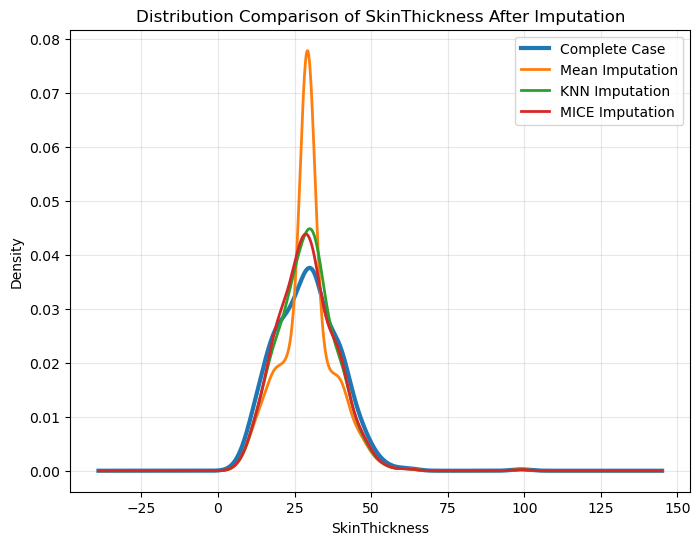

In [25]:
plt.figure(figsize=(8, 6))

# Complete case
data['SkinThickness'].dropna().plot(kind='kde', linewidth=3)

# Imputed datasets
mean_imp['SkinThickness'].plot(kind='kde', linewidth=2)
diabetes_KNN_imputed['SkinThickness'].plot(kind='kde', linewidth=2)
diabetes_mice_imputed['SkinThickness'].plot(kind='kde', linewidth=2)

plt.legend([
    'Complete Case',
    'Mean Imputation',
    'KNN Imputation',
    'MICE Imputation'
])

plt.xlabel('SkinThickness')
plt.ylabel('Density')
plt.title('Distribution Comparison of SkinThickness After Imputation')
plt.grid(alpha=0.3)
plt.show()

The complete-case distribution shows a lower peak because the observed values are more widely spread.

A slightly higher peak in the imputed datasets is expected, as imputation methods tend to place missing values near the central tendency of the conditional distribution.

## 4. Logistic Regression Model Comparison

In [26]:
def evaluate_logistic(df, name):
    X = df.drop('Diabetes', axis=1)
    y = df['Diabetes']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    return {
        'Method': name,
        'Accuracy': round(acc, 3),
        'AUC': round(auc, 3)
    }

In [27]:
results = []

results.append(evaluate_logistic(mean_imp, 'Mean'))
results.append(evaluate_logistic(median_imp, 'Median'))
results.append(evaluate_logistic(diabetes_KNN_imputed, 'KNN'))
results.append(evaluate_logistic(diabetes_mice_imputed, 'MICE'))

print(pd.DataFrame(results))

   Method  Accuracy    AUC
0    Mean     0.753  0.824
1  Median     0.753  0.823
2     KNN     0.747  0.815
3    MICE     0.747  0.816


Logistic regression performance remained highly consistent across Mean, Median, KNN, and MICE imputation methods, with only marginal differences in Accuracy and AUC.

This suggests that heavily missing variables such as Insulin may have relatively weak predictive power for diabetes classification in this dataset, making model performance less sensitive to the choice of imputation strategy.

### 4.1 VIF Analysis

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = data.drop(columns=['Diabetes']).dropna()
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif.sort_values("VIF", ascending=False))

                   variable        VIF
0                     const  54.437963
8                       Age   2.129433
6                       BMI   1.979596
1               Pregnancies   1.900719
4             SkinThickness   1.852772
2                   Glucose   1.670072
5                   Insulin   1.556143
3             BloodPressure   1.231815
7  DiabetesPedigreeFunction   1.059315


Additional VIF analysis showed no evidence of serious multicollinearity among predictors, with all variables having VIF values close to 1–2.

Therefore, the minimal performance difference across imputation methods is more likely due to Insulin itself having weak predictive power, rather than its effect being masked by collinearity with other features.

### 4.2 Coefficient Stability Across Imputation Methods

In [48]:
import pandas as pd
import statsmodels.api as sm

def get_logit_coef(df, target='Diabetes'):
    temp = df.copy()

    temp[target] = temp[target].astype(str).str.strip().str.lower()

    y = temp[target].map({'no': 0, 'yes': 1})

    print("Unique y values:", y.unique())

    X = temp.drop(columns=[target])
    X = X.apply(pd.to_numeric, errors='coerce')

    valid_idx = y.notna()
    y = y[valid_idx]
    X = X.loc[valid_idx]

    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit(disp=False)

    return model.params

coef_mean = get_logit_coef(mean_imp)
coef_mice = get_logit_coef(diabetes_mice_imputed)
coef_knn  = get_logit_coef(diabetes_KNN_imputed)

coef_table = pd.concat(
    [coef_mean, coef_knn, coef_mice],
    axis=1
)

coef_table.columns = ['Mean', 'KNN', 'MICE']

coef_table['Mean_vs_KNN'] = (coef_table['Mean'] - coef_table['KNN']).abs()
coef_table['Mean_vs_MICE'] = (coef_table['Mean'] - coef_table['MICE']).abs()
coef_table['KNN_vs_MICE'] = (coef_table['KNN'] - coef_table['MICE']).abs()

print(coef_table.round(4))

Unique y values: [1 0]
Unique y values: [1 0]
Unique y values: [1 0]
                            Mean     KNN    MICE  Mean_vs_KNN  Mean_vs_MICE  \
const                    -9.0968 -9.0175 -9.0454       0.0793        0.0514   
Pregnancies               0.1250  0.1204  0.1228       0.0046        0.0022   
Glucose                   0.0374  0.0383  0.0388       0.0010        0.0014   
BloodPressure            -0.0088 -0.0081 -0.0087       0.0007        0.0001   
SkinThickness             0.0035  0.0150  0.0054       0.0115        0.0019   
Insulin                  -0.0008 -0.0010 -0.0010       0.0002        0.0002   
BMI                       0.0931  0.0829  0.0919       0.0102        0.0013   
DiabetesPedigreeFunction  0.8661  0.5399  0.5414       0.3262        0.3247   
Age                       0.0131  0.0132  0.0132       0.0001        0.0001   

                          KNN_vs_MICE  
const                          0.0280  
Pregnancies                    0.0024  
Glucose             

To understand why classification performance remained similar across imputation methods, we compared the logistic regression coefficients estimated from each imputed dataset.

The coefficients for major predictors such as Glucose, BMI, Age, and Pregnancies remained highly consistent across Mean, KNN, and MICE imputation.

This suggests that the core decision structure of the classifier is stable, even when the underlying imputed values differ.

Although some secondary variables showed moderate variation, the overall predictive mechanism remained largely unchanged.

## 5. Conclusion


The missingness exploration suggested that the missing values in **Insulin** were more consistent with a **MAR** mechanism than with strict **MCAR**, based on repeated but subtle distributional differences across several related variables.  

Among the imputation methods, **mean imputation noticeably distorted the original variable distributions**, whereas **KNN and MICE produced distributions that were much closer to the observed complete-case patterns**. This indicates that more advanced methods were better at preserving the underlying structure of the data.  

In the linear regression analysis, **MICE achieved the highest \(R^2\)**, further suggesting stronger preservation of multivariate relationships among predictors. However, despite the clear distributional differences, **the logistic regression Accuracy and AUC remained highly similar across all methods**, indicating that diabetes classification performance was relatively robust to the imputation choice in this dataset.  

Overall, the results suggest that while **simple mean imputation may be sufficient for basic prediction tasks**, advanced methods such as **KNN and MICE are preferable when preserving the original data distribution and variable relationships is important**.

### 5.1 Insight

Although mean imputation noticeably distorted the distributions of variables such as **Insulin** and **SkinThickness**, the logistic regression **Accuracy and AUC remained highly similar across all methods**. 

A likely explanation is that these variables, despite having the largest amount of missingness, may contribute less to diabetes classification than stronger predictors such as **Glucose, BMI, and Age**. 

As a result, the downstream prediction task appears to be driven primarily by these more robust predictors, making the model relatively insensitive to the specific imputation method used.

The choice of imputation method may matter less when variables with high missingness are weak predictors of the target.

### 5.2 Limitation
- This analysis is based on a single diabetes dataset, so the findings may not generalize to datasets where variables with heavy missingness are stronger predictors of the target outcome. 

- In addition, the missingness mechanism was inferred through exploratory visualizations, which provide supporting evidence but cannot definitively prove a MAR assumption.